# Guardrail Check
## Final decision: guardrail = 0.35

Inspect retrieval scores per query and tune the refusal threshold.

In [51]:
import os, sys, json
import pandas as pd

HERE    = os.path.abspath(".")
BACKEND = os.path.join(HERE, '..', 'backend-fastapi')
sys.path.insert(0, BACKEND)
os.environ.setdefault("CHROMA_PATH", os.path.join(BACKEND, 'chroma_db'))

from dotenv import load_dotenv
load_dotenv(os.path.join(BACKEND, '.env'))

from scripts.search_chroma import search

guardrail_queries = json.load(open("guardrail_queries.json"))["queries"]
test_queries      = [
    {"query": q["query"], "expected": "refuse" if q["type"] == "off-topic" else "answer", "note": q["type"]}
    for q in json.load(open("test_queries.json"))["queries"]
]

def score_queries(query_data):
    rows = []
    for q in query_data:
        results = search(q["query"], k=5)
        scores = [1 - r["distance"] for r in results]
        rows.append({
            "expected":   q["expected"],
            "note":       q.get("note", ""),
            "query":      q["query"],
            "max_score":  round(max(scores), 4),
            "mean_score": round(sum(scores) / len(scores), 4),
            "min_score":  round(min(scores), 4),
            "scores":     [round(s, 4) for s in scores],
        })
    return pd.DataFrame(rows).sort_values("max_score", ascending=False)

## Retrieval scores per query\nShows the max, min, and mean cosine similarity across the top-5 retrieved articles for each query.

In [52]:
df_guardrail = score_queries(guardrail_queries)
df_guardrail.style.background_gradient(subset=["max_score", "mean_score"], cmap="RdYlGn")

,expected,note,query,max_score,mean_score,min_score,scores
5,answer,cs.IR core,BM25 ranking for document retrieval,0.644800,0.515000,0.438700,"[0.6448, 0.5269, 0.4843, 0.4802, 0.4387]"
11,borderline,"cs.CV — passes embedding, LLM should answer (cross-lists cs.CL)",multimodal vision-language pretraining,0.639700,0.593100,0.550000,"[0.6397, 0.6155, 0.5853, 0.575, 0.55]"
6,answer,cs.IR + cs.CL core,dense passage retrieval for open-domain question answering,0.557900,0.498700,0.465100,"[0.5579, 0.522, 0.4759, 0.4723, 0.4651]"
13,borderline,"cs.CV — passes embedding due to ML vocabulary, LLM should decline",convolutional neural networks for image classification,0.527800,0.376300,0.303100,"[0.5278, 0.3707, 0.3706, 0.3095, 0.3031]"
1,answer,cs.CL core,BERT fine-tuning for text classification,0.521100,0.497600,0.483300,"[0.5211, 0.5002, 0.494, 0.4894, 0.4833]"
0,answer,cs.CL core,neural machine translation with attention mechanisms,0.496600,0.484200,0.474900,"[0.4966, 0.4897, 0.4808, 0.479, 0.4749]"
2,answer,cs.CL core,named entity recognition with transformer models,0.481400,0.442400,0.413700,"[0.4814, 0.4469, 0.4447, 0.4252, 0.4137]"
8,answer,cs.IR core,learning to rank documents with listwise loss,0.480000,0.441700,0.419000,"[0.48, 0.4668, 0.423, 0.4199, 0.419]"
14,borderline,"cs.NI — passes embedding due to CS vocabulary, LLM should decline",TCP congestion control algorithms,0.470500,0.245700,0.165400,"[0.4705, 0.244, 0.1776, 0.1709, 0.1654]"
9,borderline,"eess.AS — passes embedding, LLM should answer (cross-lists cs.CL)",speech recognition with deep neural networks,0.463500,0.407100,0.378100,"[0.4635, 0.4265, 0.3848, 0.3824, 0.3781]"


## Threshold simulator
Change `THRESHOLD` below and see which queries would be refused vs. answered.

In [53]:
THRESHOLD = 0.35

def simulate(df):
    def verdict(row):
        refused  = row["max_score"] < THRESHOLD
        expected = row["expected"]
        if refused and expected == "refuse":
            return "✅ correctly refused"
        elif not refused and expected == "answer":
            return "✅ correctly answered"
        elif refused and expected == "answer":
            return "❌ wrongly refused"
        elif not refused and expected == "refuse":
            return "⚠️  should have been refused"
        else:
            return f"{'refused' if refused else 'answered'} (borderline)"
    sim = df.copy()
    sim["verdict"] = sim.apply(verdict, axis=1)
    return sim[["expected", "query", "note", "max_score", "verdict"]]

pd.set_option("display.max_colwidth", None)
simulate(df_guardrail)

,expected,query,note,max_score,verdict
5,answer,BM25 ranking for document retrieval,cs.IR core,0.6448,✅ correctly answered
11,borderline,multimodal vision-language pretraining,"cs.CV — passes embedding, LLM should answer (cross-lists cs.CL)",0.6397,answered (borderline)
6,answer,dense passage retrieval for open-domain question answering,cs.IR + cs.CL core,0.5579,✅ correctly answered
13,borderline,convolutional neural networks for image classification,"cs.CV — passes embedding due to ML vocabulary, LLM should decline",0.5278,answered (borderline)
1,answer,BERT fine-tuning for text classification,cs.CL core,0.5211,✅ correctly answered
0,answer,neural machine translation with attention mechanisms,cs.CL core,0.4966,✅ correctly answered
2,answer,named entity recognition with transformer models,cs.CL core,0.4814,✅ correctly answered
8,answer,learning to rank documents with listwise loss,cs.IR core,0.4800,✅ correctly answered
14,borderline,TCP congestion control algorithms,"cs.NI — passes embedding due to CS vocabulary, LLM should decline",0.4705,answered (borderline)
9,borderline,speech recognition with deep neural networks,"eess.AS — passes embedding, LLM should answer (cross-lists cs.CL)",0.4635,answered (borderline)


## Cross-check: evaluation test queries\nSame threshold applied to `test_queries.json` — to verify consistency.

## Score distributions by expected outcome\nShows where answer, borderline, and refuse queries land — the gap between them is where to set the threshold.

In [54]:
df_test = score_queries(test_queries)
df_test.style.background_gradient(subset=["max_score", "mean_score"], cmap="RdYlGn")

,expected,note,query,max_score,mean_score,min_score,scores
6,answer,borderline,deep learning applications in healthcare,0.553700,0.406200,0.344400,"[0.5537, 0.3916, 0.3789, 0.3624, 0.3444]"
2,answer,on-topic,large language models for biomedical named entity recognition,0.507700,0.486700,0.451900,"[0.5077, 0.5075, 0.5034, 0.4632, 0.4519]"
1,answer,on-topic,federated learning for clinical data privacy,0.496000,0.375800,0.329700,"[0.496, 0.375, 0.3455, 0.3326, 0.3297]"
4,answer,on-topic,attention mechanisms for protein structure prediction,0.452500,0.403000,0.383000,"[0.4525, 0.4085, 0.3867, 0.3841, 0.383]"
0,answer,on-topic,transformer architectures for medical image segmentation,0.409700,0.296700,0.233200,"[0.4097, 0.3018, 0.2894, 0.2493, 0.2332]"
5,answer,multilingual,aprendizaje automático para clasificación de texto clínico,0.407500,0.339200,0.310300,"[0.4075, 0.347, 0.3163, 0.315, 0.3103]"
3,answer,on-topic,graph neural networks for drug-target interaction prediction,0.398200,0.303800,0.273300,"[0.3982, 0.2879, 0.2849, 0.2745, 0.2733]"
8,refuse,off-topic,quantum computing error correction algorithms,0.265100,0.241700,0.216500,"[0.2651, 0.2556, 0.2481, 0.2229, 0.2165]"
7,refuse,off-topic,history of the Roman Empire,0.170300,0.134100,0.100800,"[0.1703, 0.1701, 0.1192, 0.1098, 0.1008]"


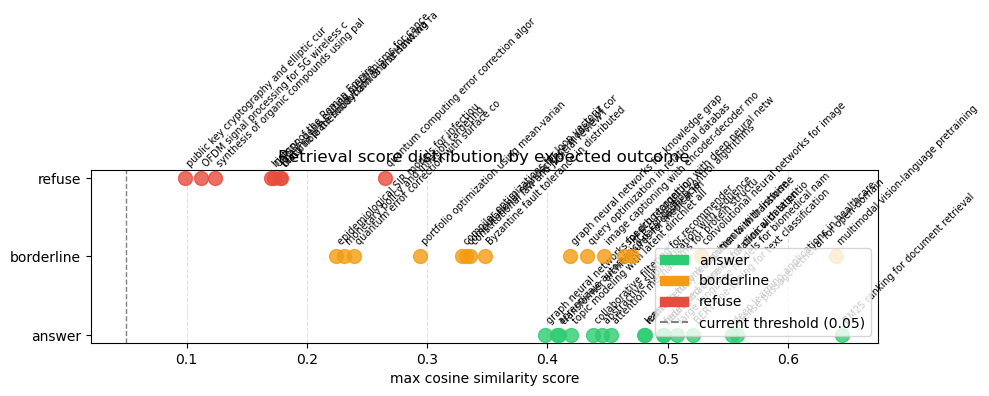

In [55]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_all = pd.concat([df_guardrail, df_test], ignore_index=True).drop_duplicates(subset="query")

colors   = {"answer": "#2ecc71", "borderline": "#f39c12", "refuse": "#e74c3c"}
labels   = {"answer": "answer", "borderline": "borderline", "refuse": "refuse"}
fig, ax  = plt.subplots(figsize=(10, 4))

for group, gdf in df_all.groupby("expected"):
    ax.scatter(
        gdf["max_score"],
        [group] * len(gdf),
        color=colors.get(group, "grey"),
        s=100, zorder=3, alpha=0.8,
    )
    for _, row in gdf.iterrows():
        ax.annotate(
            row["query"][:40],
            (row["max_score"], group),
            textcoords="offset points", xytext=(0, 8),
            fontsize=7, rotation=45, ha="left",
        )

ax.axvline(0.05, color="grey",  linestyle="--", linewidth=1, label="current threshold (0.05)")
ax.set_xlabel("max cosine similarity score")
ax.set_title("Retrieval score distribution by expected outcome")
ax.grid(axis="x", linestyle="--", alpha=0.4)
patches = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0], color="grey", linestyle="--", label="current threshold (0.05)")],
          loc="lower right")
plt.tight_layout()
plt.show()

In [56]:
df_test = score_queries(test_queries)
simulate(df_test)

,expected,query,note,max_score,verdict
6,answer,deep learning applications in healthcare,borderline,0.5537,✅ correctly answered
2,answer,large language models for biomedical named entity recognition,on-topic,0.5077,✅ correctly answered
1,answer,federated learning for clinical data privacy,on-topic,0.4960,✅ correctly answered
4,answer,attention mechanisms for protein structure prediction,on-topic,0.4525,✅ correctly answered
0,answer,transformer architectures for medical image segmentation,on-topic,0.4097,✅ correctly answered
5,answer,aprendizaje automático para clasificación de texto clínico,multilingual,0.4075,✅ correctly answered
3,answer,graph neural networks for drug-target interaction prediction,on-topic,0.3982,✅ correctly answered
8,refuse,quantum computing error correction algorithms,off-topic,0.2651,✅ correctly refused
7,refuse,history of the Roman Empire,off-topic,0.1703,✅ correctly refused
